# Demographics exploration

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
tracts = gpd.read_file("data/philly_tracts.gpkg")
neighborhoods = gpd.read_file("data/philadelphia-neighborhoods.gpkg")
tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,index_right,MAPNAME,geometry
0,42,101,020500,42101020500,1400000US42101020500,205,Census Tract 205,G5020,S,1429513,0,+40.0158738,-075.1643607,62,Tioga,"POLYGON ((2689452.729 259213.458, 2689576.162 ..."
1,42,101,020500,42101020500,1400000US42101020500,205,Census Tract 205,G5020,S,1429513,0,+40.0158738,-075.1643607,58,Southwest Germantown,"POLYGON ((2689452.729 259213.458, 2689576.162 ..."
2,42,101,020500,42101020500,1400000US42101020500,205,Census Tract 205,G5020,S,1429513,0,+40.0158738,-075.1643607,61,Nicetown,"POLYGON ((2689452.729 259213.458, 2689576.162 ..."
3,42,101,020500,42101020500,1400000US42101020500,205,Census Tract 205,G5020,S,1429513,0,+40.0158738,-075.1643607,89,Logan,"POLYGON ((2689452.729 259213.458, 2689576.162 ..."
4,42,101,020600,42101020600,1400000US42101020600,206,Census Tract 206,G5020,S,1295909,56782,+40.0197999,-075.1827740,63,Allegheny West,"POLYGON ((2684720.175 260695.467, 2684866.848 ..."


In [8]:
tracts.crs

<Projected CRS: EPSG:2272>
Name: NAD83 / Pennsylvania South (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
- bounds: (-80.53, 39.71, -74.72, 41.18)
Coordinate Operation:
- name: SPCS83 Pennsylvania South zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [3]:
tracts_sub = tracts[['TRACTCE', 'GEOID', 'NAME', 'geometry']]

In [4]:
neigh_reviews_subset = gpd.read_file("modified_data/neigh_reviews_subset.gpkg")
neigh_reviews_subset.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'index_right', 'LISTNAME',
       'gentrified', 'review_id', 'user_id', 'useful', 'funny', 'cool', 'text',
       'date', 'geometry'],
      dtype='object')

In [5]:
neigh_reviews_subset = neigh_reviews_subset.drop('index_right', axis=1)
neigh_reviews_subset = neigh_reviews_subset.to_crs(tracts.crs)
neigh_reviews_subset.crs

<Projected CRS: EPSG:2272>
Name: NAD83 / Pennsylvania South (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
- bounds: (-80.53, 39.71, -74.72, 41.18)
Coordinate Operation:
- name: SPCS83 Pennsylvania South zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [6]:
neigh_reviews_subset.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'LISTNAME', 'gentrified',
       'review_id', 'user_id', 'useful', 'funny', 'cool', 'text', 'date',
       'geometry'],
      dtype='object')

In [7]:
# reviews joined with location info (neighborhood, tract)
reviews_loc = gpd.sjoin(neigh_reviews_subset, tracts_sub, how="left", predicate="intersects")
reviews_loc.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,useful,funny,cool,text,date,geometry,index_right,TRACTCE,GEOID,NAME
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,0.0,1.0,This is nice little Chinese bakery in the hear...,2014-05-26 01:09:53,POINT (2695729.449 237331.978),303.0,000200,42101000200,2
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,0.0,1.0,This is nice little Chinese bakery in the hear...,2014-05-26 01:09:53,POINT (2695729.449 237331.978),304.0,000200,42101000200,2
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,0.0,1.0,This is nice little Chinese bakery in the hear...,2014-05-26 01:09:53,POINT (2695729.449 237331.978),306.0,000200,42101000200,2
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,0.0,1.0,This is nice little Chinese bakery in the hear...,2014-05-26 01:09:53,POINT (2695729.449 237331.978),305.0,000200,42101000200,2
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,3.0,1.0,2.0,This is the bakery I usually go to in Chinatow...,2013-10-05 15:19:06,POINT (2695729.449 237331.978),303.0,000200,42101000200,2


In [8]:
len(reviews_loc['NAME'].unique())

371

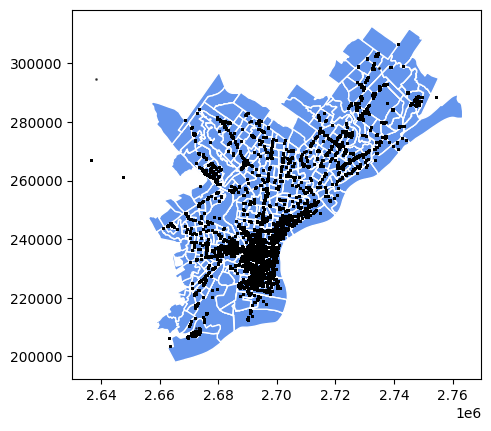

In [9]:

ax = tracts.plot(color="cornflowerblue",edgecolor="white")
reviews_loc.plot(ax=ax, markersize= 1, color="black", alpha=0.6)
plt.show()

## Merge with race and ethnicity data 

In [10]:
reviews_loc.dtypes

business_id        object
name               object
address            object
city               object
state              object
postal_code_x      object
latitude          float64
longitude         float64
stars             float64
review_count        int64
is_open             int64
attributes         object
categories         object
hours              object
LISTNAME           object
gentrified        float64
review_id          object
user_id            object
useful            float64
funny             float64
cool              float64
text               object
date               object
geometry         geometry
index_right       float64
TRACTCE            object
GEOID              object
NAME               object
dtype: object

In [11]:
race = pd.read_csv("modified_data/race_ethn_cleaned.csv")
reviews_loc['TRACTCE'] = reviews_loc['TRACTCE'].astype(str).str.zfill(6)
race['TRACTCE'] = race['TRACTCE'].astype(str).str.zfill(6)
reviews_demog = pd.merge(reviews_loc, race, how="left", on="TRACTCE")
reviews_demog.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,GEOID,NAME,Unnamed: 0,geography,geographic_area_name,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837


In [12]:
reviews_demog = reviews_demog.rename(columns={"LISTNAME": "neighborhood"})

### Create demographic indicators

In [13]:
neighborhoods = neighborhoods.to_crs(reviews_demog.crs)
neighborhoods = neighborhoods.rename(columns={"LISTNAME": "neighborhood"})

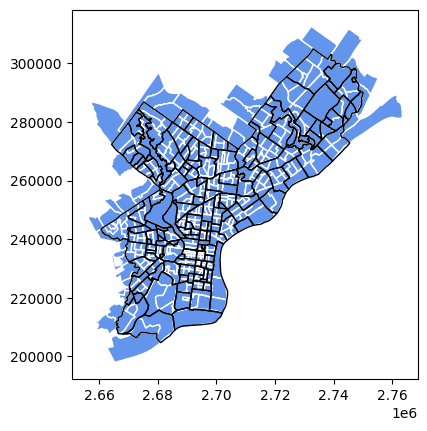

In [14]:
ax = tracts.plot(color="cornflowerblue",edgecolor="white")
neighborhoods.plot(ax=ax, facecolor="none", edgecolor="black", alpha=1)
plt.show()

In [15]:
tract_neigh_intersection = gpd.overlay(tracts_sub, neighborhoods, how="intersection")
tract_neigh_intersection['overlap_area'] = tract_neigh_intersection.geometry.area

In [16]:
tract_neigh_intersection.head()

,TRACTCE,GEOID,NAME_1,NAME_2,neighborhood,MAPNAME,Shape_Leng,Shape_Area,geometry,overlap_area
0,020500,42101020500,205,GERMANTOWN_SOUTHWEST,"Germantown, Southwest",Southwest Germantown,14880.743608,1.441867e+07,"POLYGON ((2692793.233 260511.916, 2692808.668 ...",8.445293e+05
1,020500,42101020500,205,NICETOWN,Nicetown,Nicetown,11237.318154,6.587596e+06,"POLYGON ((2694620.731 261016.698, 2694654.414 ...",4.481298e+06
2,020500,42101020500,205,TIOGA,Tioga,Tioga,27189.667081,3.162796e+07,"MULTIPOLYGON (((2689576.162 259314.363, 268967...",9.580624e+06
3,020500,42101020500,205,LOGAN,Logan,Logan,29512.474658,3.903897e+07,"POLYGON ((2693881.229 262212.583, 2693952.798 ...",4.802851e+05
4,020500,42101020500,205,GERMANTOWN_SOUTHWEST,"Germantown, Southwest",Southwest Germantown,14880.743608,1.441867e+07,"POLYGON ((2692793.233 260511.916, 2692808.668 ...",8.445293e+05


In [17]:
reviews_demog = reviews_demog.merge(
    tract_neigh_intersection[['TRACTCE', "neighborhood", "overlap_area"]],
    on=['TRACTCE', "neighborhood"],
    how="left"
)
reviews_demog.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,NAME,Unnamed: 0,geography,geographic_area_name,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,overlap_area
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837,1.243334e+06
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837,1.243334e+06
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837,1.243334e+06
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837,1.243334e+06
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837,1.243334e+06


In [18]:
# find tracts that are predominantly POC
# get weighted proportion white only for each neighborhood
weighted_white = (
    reviews_demog
    .groupby("neighborhood")
    .apply(lambda x: (x["prop_white_only"] * x["overlap_area"]).sum() / x["overlap_area"].sum())
    .reset_index(name="prop_white_wavg")
)

weighted_white

/var/folders/rz/h3gzrv2j09s6d_5vmn0bglw40000gn/T/ipykernel_83785/3631529231.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["prop_white_only"] * x["overlap_area"]).sum() / x["overlap_area"].sum())


,neighborhood,prop_white_wavg
0,Academy Gardens,0.760686
1,Airport,0.040221
2,Allegheny West,0.221730
3,Andorra,0.802986
4,Aston-Woodbridge,0.549731
...,...,...
143,Wister,0.063418
144,Woodland Terrace,0.456125
145,Wynnefield,0.184475
146,Wynnefield Heights,0.266426


(array([13., 13.,  7.,  4.,  5.,  1.,  1.,  3.,  2.,  1.,  1.,  4.,  5.,
         2.,  2.,  1.,  3.,  2.,  2.,  4.,  2.,  1.,  5.,  3.,  1.,  3.,
         1.,  2.,  3.,  2.,  2.,  3.,  5.,  2.,  3.,  5.,  5.,  3.,  4.,
         8.,  4.,  1.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  2.]),
 array([0.01844151, 0.03807268, 0.05770385, 0.07733502, 0.09696619,
        0.11659736, 0.13622853, 0.1558597 , 0.17549087, 0.19512204,
        0.21475321, 0.23438438, 0.25401555, 0.27364672, 0.29327789,
        0.31290905, 0.33254022, 0.35217139, 0.37180256, 0.39143373,
        0.4110649 , 0.43069607, 0.45032724, 0.46995841, 0.48958958,
        0.50922075, 0.52885192, 0.54848309, 0.56811426, 0.58774543,
        0.6073766 , 0.62700777, 0.64663894, 0.66627011, 0.68590128,
        0.70553245, 0.72516362, 0.74479479, 0.76442596, 0.78405713,
        0.8036883 , 0.82331947, 0.84295064, 0.86258181, 0.88221298,
        0.90184415, 0.92147532, 0.94110649, 0.96073766, 0.98036883,
        1.        ]),
 <BarContainer

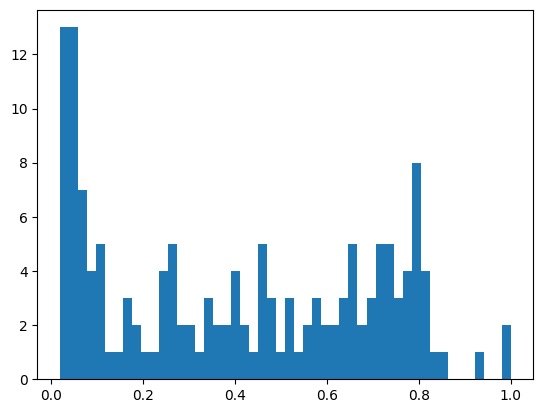

In [19]:
plt.hist(weighted_white['prop_white_wavg'], bins=50)

In [20]:
reviews_demog = pd.merge(reviews_demog,weighted_white,  how="left", on="neighborhood")
reviews_demog.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,Unnamed: 0,geography,geographic_area_name,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,overlap_area,prop_white_wavg
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837,1.243334e+06,0.243837
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837,1.243334e+06,0.243837
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837,1.243334e+06,0.243837
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837,1.243334e+06,0.243837
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837,1.243334e+06,0.243837


In [21]:
reviews_demog['predom_poc'] = np.where(reviews_demog['prop_white_wavg'] < 0.4, 1, 0)
reviews_demog['no_predom_race'] = np.where((reviews_demog['prop_white_wavg'] > 0.4) & (reviews_demog['prop_white_wavg'] < 0.6), 1, 0)

In [23]:
reviews_demog.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'neighborhood', 'gentrified',
       'review_id', 'user_id', 'useful', 'funny', 'cool', 'text', 'date',
       'geometry', 'TRACTCE', 'GEOID', 'geographic_area_name', 'tot_pop',
       'prop_black', 'prop_asian', 'prop_hispanic_or_latino',
       'prop_white_only', 'overlap_area', 'prop_white_wavg', 'predom_poc',
       'no_predom_race'],
      dtype='object')

In [22]:

reviews_demog = reviews_demog.drop(columns=["NAME", "index_right", "Unnamed: 0", "geography"])
reviews_demog.to_file("modified_data/reviews_demog.gpkg")

In [ ]:
reviews_demog = gpd.read_file("modified_data/reviews_demog.gpkg")
reviews_demog.columns

## Descriptive stats + exploration

In [114]:
pd.crosstab(reviews_demog['predom_poc'], reviews_demog['gentrified'], normalize=True)

gentrified,0.0,1.0
predom_poc,,
0,0.665050,0.088038
1,0.234838,0.012074


In [124]:
pd.crosstab(reviews_demog['no_predom_race'], reviews_demog['gentrified'], normalize=True)

gentrified,0.0,1.0
no_predom_race,,
0,0.677359,0.069066
1,0.222529,0.031046


In [ ]:
# gentrified predominantly POC neighborhoods (> 60% nonwhite)
gentrified_poc = reviews_demog[(reviews_demog['predom_poc'] == 1) & (reviews_demog['gentrified'] == 1)]
poc_gentrified_neighborhoods = gentrified_poc['neighborhood'].unique()
poc_gentrified_neighborhoods

array(['Olney', 'Cobbs Creek', 'Mount Airy, East', 'Southwest Schuylkill'],
      dtype=object)

In [126]:
# gentrified predominantly white neighborhoods (< 40% nonwhite)
gentrified_white = reviews_demog[(reviews_demog['predom_poc'] == 0) & (reviews_demog['no_predom_race'] == 0) & (reviews_demog['gentrified'] == 1)]
white_gentrified_neighborhoods = gentrified_white['neighborhood'].unique()
white_gentrified_neighborhoods

array(['Logan Square', 'Fishtown - Lower Kensington', 'Roxborough',
       'East Falls', 'Fairmount', 'Upper Roxborough', 'Roxborough Park'],
      dtype=object)

In [125]:
# gentrified mixed race neighborhoods (between 40% and 60% nonwhite)
gentrified_mixed = reviews_demog[(reviews_demog['no_predom_race'] == 1) & (reviews_demog['gentrified'] == 1)]
mixed_gentrified_neighborhoods = gentrified_mixed['neighborhood'].unique()
mixed_gentrified_neighborhoods

array(['Callowhill'], dtype=object)